# IMU Aerodynamic Force Extraction from Foxglove CSVs

**Inputs** (one CSV per signal):
- `angular_velocity_{x,y,z}.csv` : IMU gyro (body frame)
- `linear_acceleration_{x,y,z}.csv` : IMU accel (specific force in body frame)
- `pos_{x,y,z}.csv` : mocap position in world frame
- `pos_orientation_{x,y,z,w}.csv` : mocap orientation (quaternion)
- `twist_linear_{x,y,z}.csv` : mocap linear velocity in world frame
- `twist_angular_{x,y,z}.csv` : mocap angular velocity in world frame (optional for now)
- `average_motor_speed.csv` : average rotor RPM (all 4 motors)

**Output**:
- combined DataFrame with body-frame velocities, total acceleration,
  crude aerodynamic force estimate, and quick sanity plots.

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import savgol_filter

from transforms3d.quaternions import quat2mat

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print("Libraries imported.")

Libraries imported.


## 1. Configuration

In [70]:
# Folder with all CSVs
#data_dir = Path("/home/nebu/Documents/TUM/Masterarbeit/MasterTheses/logs/Circle/8mps_imu")
data_dir = Path("/home/nebu/Documents/TUM/Masterarbeit/MasterTheses/logs/Circle/12mps_line")

# Physical parameters
mass = 2.5        # kg  (adjust to your platform)
g = 9.81          # m/s^2
rho = 1.225       # kg/m^3 (if you need it later)
n_motors = 4      # X-wing quad

# Quick check that files exist
files = [
    "angular_velocity_x.csv",
    "angular_velocity_y.csv",
    "angular_velocity_z.csv",
    "linear_acceleration_x.csv",
    "linear_acceleration_y.csv",
    "linear_acceleration_z.csv",
    "pos_x.csv", "pos_y.csv", "pos_z.csv",
    "pos_orientation_x.csv", "pos_orientation_y.csv",
    "pos_orientation_z.csv", "pos_orientation_w.csv",
    "twist_linear_x.csv", "twist_linear_y.csv", "twist_linear_z.csv",
    "average_motor_speed.csv",
]

missing = [f for f in files if not (data_dir / f).exists()]
if missing:
    print("⚠️ Missing files:", missing)
else:
    print("✓ All expected files found.")

✓ All expected files found.


## 2. Helper to Load Single Time Series

In [71]:
# Helper to load a single time series from a CSV
#
# Foxglove CSV format: elapsed time, timestamp, topic, value
# We'll use "elapsed time" (in seconds) and "value" columns.

def load_series(filename: str, value_name: str) -> pd.DataFrame:
    path = data_dir / filename
    df = pd.read_csv(path)

    # Expect Foxglove format: elapsed time, timestamp, topic, value
    cols = list(df.columns)
    print(f"{filename} columns:", cols)

    if "elapsed time" in df.columns and "value" in df.columns:
        t_col = "elapsed time"   # or "timestamp" if you prefer absolute time
        v_col = "value"
    else:
        raise ValueError(f"{filename}: unexpected columns {cols} – adjust loader.")

    out = df[[t_col, v_col]].copy()
    out = out.rename(columns={t_col: "t", v_col: value_name})

    # No nanosecond heuristic anymore; Foxglove already gives seconds
    return out

# Quick smoke test on one file
test_df = load_series("linear_acceleration_x.csv", "ax_b")
print(test_df.head())


linear_acceleration_x.csv columns: ['elapsed time', 'timestamp', 'topic', 'value']
          t     ax_b
0  0.002440  0.06867
1  0.002465  0.00000
2  0.002491  0.08829
3  0.002527  0.23544
4  0.007557  0.21582


## 3. Load All Series

In [72]:
# IMU – specific force (body frame)
ax_df = load_series("linear_acceleration_x.csv", "ax_b")
ay_df = load_series("linear_acceleration_y.csv", "ay_b")
az_df = load_series("linear_acceleration_z.csv", "az_b")

# IMU – gyro (body frame)
wx_df = load_series("angular_velocity_x.csv", "wx_b")
wy_df = load_series("angular_velocity_y.csv", "wy_b")
wz_df = load_series("angular_velocity_z.csv", "wz_b")

# Mocap – position (world frame)
px_df = load_series("pos_x.csv", "px_w")
py_df = load_series("pos_y.csv", "py_w")
pz_df = load_series("pos_z.csv", "pz_w")

# Mocap – orientation (quaternion)
qx_df = load_series("pos_orientation_x.csv", "qx_w")
qy_df = load_series("pos_orientation_y.csv", "qy_w")
qz_df = load_series("pos_orientation_z.csv", "qz_w")
qw_df = load_series("pos_orientation_w.csv", "qw_w")

# Mocap – linear velocity (world frame)
vx_df = load_series("twist_linear_x.csv", "vx_w")
vy_df = load_series("twist_linear_y.csv", "vy_w")
vz_df = load_series("twist_linear_z.csv", "vz_w")

# Motor – average RPM (multiply by 10 to correct CSV data error)
rpm_avg_df = load_series("average_motor_speed.csv", "rpm_avg")
rpm_avg_df["rpm_avg"] = rpm_avg_df["rpm_avg"] * 10

print("Loaded all series.")


linear_acceleration_x.csv columns: ['elapsed time', 'timestamp', 'topic', 'value']
linear_acceleration_y.csv columns: ['elapsed time', 'timestamp', 'topic', 'value']
linear_acceleration_z.csv columns: ['elapsed time', 'timestamp', 'topic', 'value']
angular_velocity_x.csv columns: ['elapsed time', 'timestamp', 'topic', 'value']
angular_velocity_y.csv columns: ['elapsed time', 'timestamp', 'topic', 'value']
angular_velocity_z.csv columns: ['elapsed time', 'timestamp', 'topic', 'value']
pos_x.csv columns: ['elapsed time', 'timestamp', 'topic', 'value']
pos_y.csv columns: ['elapsed time', 'timestamp', 'topic', 'value']
pos_z.csv columns: ['elapsed time', 'timestamp', 'topic', 'value']
pos_orientation_x.csv columns: ['elapsed time', 'timestamp', 'topic', 'value']
pos_orientation_y.csv columns: ['elapsed time', 'timestamp', 'topic', 'value']
pos_orientation_z.csv columns: ['elapsed time', 'timestamp', 'topic', 'value']
pos_orientation_w.csv columns: ['elapsed time', 'timestamp', 'topic', 'va

## 4. Merge and Time-Align All Series

In [73]:
# Merge all series into a single time-aligned DataFrame
#
# Strategy:
# - Outer-merge everything on 't'
# - Sort by time
# - Interpolate missing values linearly in time
#   (Orientation will still be interpolated componentwise; we fix that below.)

dfs = [
    ax_df, ay_df, az_df,
    wx_df, wy_df, wz_df,
    px_df, py_df, pz_df,
    qx_df, qy_df, qz_df, qw_df,
    vx_df, vy_df, vz_df,
    rpm_avg_df,
]

combined = dfs[0]
for df in dfs[1:]:
    combined = pd.merge(combined, df, on="t", how="outer")

combined = combined.sort_values("t").reset_index(drop=True)

print("Before interpolation, NaN counts:")
print(combined.isna().sum())

# Interpolation in time
combined_interp = combined.set_index("t").interpolate(method="index").reset_index()

print("\nAfter interpolation, NaN counts:")
print(combined_interp.isna().sum())

# Use this as our main DataFrame now
combined = combined_interp.copy()

t_rel = combined["t"] - combined["t"].min()
print(f"\nCombined duration: {t_rel.max():.3f} s, samples: {len(combined)}")

Before interpolation, NaN counts:
t              0
ax_b       14519
ay_b       14519
az_b       14519
wx_b       14519
wy_b       14519
wz_b       14519
px_w       20869
py_w       20869
pz_w       20869
qx_w       20869
qy_w       20869
qz_w       20869
qw_w       20869
vx_w       20848
vy_w       20848
vz_w       20848
rpm_avg    14516
dtype: int64

After interpolation, NaN counts:
t           0
ax_b        6
ay_b        6
az_b        6
wx_b        6
wy_b        6
wz_b        6
px_w       11
py_w       11
pz_w       11
qx_w       11
qy_w       11
qz_w       11
qw_w       11
vx_w        0
vy_w        0
vz_w        0
rpm_avg     2
dtype: int64

Combined duration: 9.114 s, samples: 23584


## 5. Fix Orientation Interpolation

In [74]:
# Fix orientation interpolation (nearest neighbor instead of linear)
#
# Linear interpolation of quaternions is garbage. We do a crude fix:
# - Re-load the raw quaternion series
# - Merge with time
# - For each time index, take the nearest quat sample
#
# This is not SLERP, but it's at least not mathematically broken.

quat_raw = (
    qx_df
    .merge(qy_df, on="t", how="outer")
    .merge(qz_df, on="t", how="outer")
    .merge(qw_df, on="t", how="outer")
    .sort_values("t")
    .reset_index(drop=True)
)

# Nearest neighbor mapping of raw quat to combined time grid
quat_raw_idx = quat_raw.set_index("t")
combined_idx = combined.set_index("t")

quat_nn = quat_raw_idx.reindex(combined_idx.index, method="nearest")

combined["qx_w"] = quat_nn["qx_w"].values
combined["qy_w"] = quat_nn["qy_w"].values
combined["qz_w"] = quat_nn["qz_w"].values
combined["qw_w"] = quat_nn["qw_w"].values

print("Replaced orientation with nearest-neighbor samples.")

Replaced orientation with nearest-neighbor samples.


## 6. Quick Sanity Plots

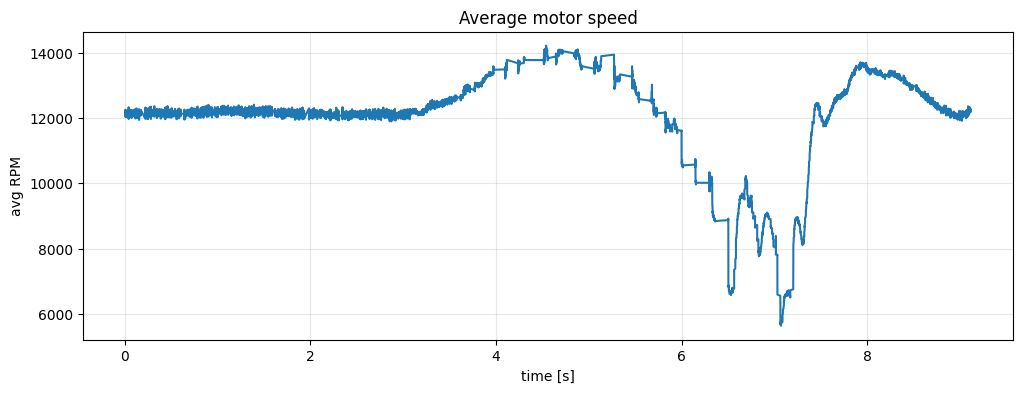

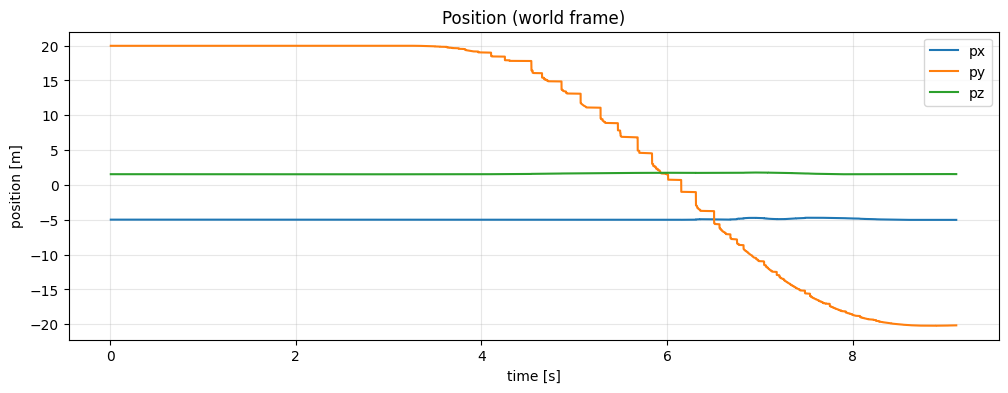

In [75]:
# Quick sanity plots: RPM and position vs time

t_rel = combined["t"] - combined["t"].min()

plt.figure(figsize=(12, 4))
plt.plot(t_rel, combined["rpm_avg"])
plt.xlabel("time [s]")
plt.ylabel("avg RPM")
plt.title("Average motor speed")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(t_rel, combined["px_w"], label="px")
plt.plot(t_rel, combined["py_w"], label="py")
plt.plot(t_rel, combined["pz_w"], label="pz")
plt.xlabel("time [s]")
plt.ylabel("position [m]")
plt.title("Position (world frame)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Rotation: World → Body

In [76]:
# Rotation: world -> body
#
# Assume quaternion (qw_w, qx_w, qy_w, qz_w) is body->world (standard ROS Pose).
# Then world->body is the transpose of that rotation matrix.

def R_world_to_body(qw, qx, qy, qz):
    R_bw = quat2mat([qw, qx, qy, qz])  # body -> world
    R_wb = R_bw.T                      # world -> body
    return R_wb

## 7a. Compute Gravity in Body Frame

In [77]:
# Compute gravity vector in body frame for each timestamp
# This is useful to verify IMU measurements and orientation accuracy

g_world = np.array([0.0, 0.0, -g])

g_b_list = []
for _, row in combined.iterrows():
    R_wb = R_world_to_body(row["qw_w"], row["qx_w"], row["qy_w"], row["qz_w"])
    g_b = R_wb @ g_world
    g_b_list.append(g_b)

g_b = np.vstack(g_b_list)
combined["gx_b"] = g_b[:, 0]
combined["gy_b"] = g_b[:, 1]
combined["gz_b"] = g_b[:, 2]

print("Gravity vector in body frame computed.")

Gravity vector in body frame computed.


## 7b. Sanity Check: IMU vs Gravity Projection

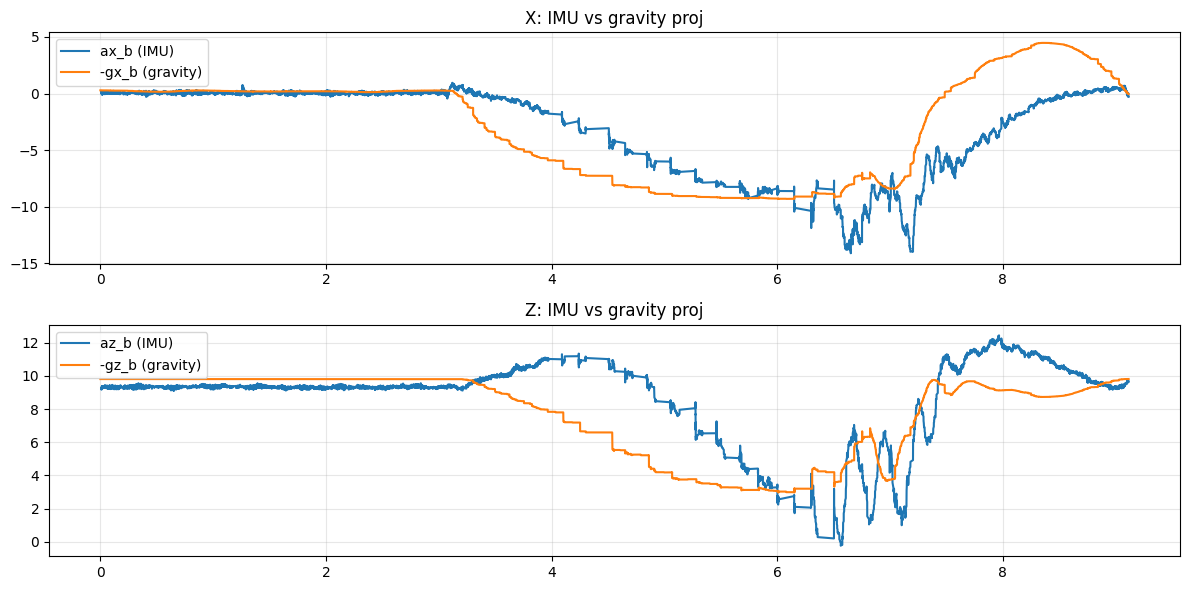

In [78]:
# Plot IMU specific force vs gravity projection in body frame
# If orientation is correct, -g_b should match ax_b, ay_b, az_b during hover

t_rel = combined["t"] - combined["t"].min()

plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.plot(t_rel, combined["ax_b"], label="ax_b (IMU)")
plt.plot(t_rel, -combined["gx_b"], label="-gx_b (gravity)")
plt.legend(); plt.grid(True, alpha=0.3); plt.title("X: IMU vs gravity proj")

plt.subplot(2,1,2)
plt.plot(t_rel, combined["az_b"], label="az_b (IMU)")
plt.plot(t_rel, -combined["gz_b"], label="-gz_b (gravity)")
plt.legend(); plt.grid(True, alpha=0.3); plt.title("Z: IMU vs gravity proj")

plt.tight_layout()
plt.show()

## 8. Compute Body-Frame Velocity

In [79]:
# Compute body-frame velocity from world-frame velocity

v_b_list = []

for _, row in combined.iterrows():
    R_wb = R_world_to_body(row["qw_w"], row["qx_w"], row["qy_w"], row["qz_w"])
    v_w = np.array([row["vx_w"], row["vy_w"], row["vz_w"]])
    v_b = R_wb @ v_w
    v_b_list.append(v_b)

v_b = np.vstack(v_b_list)
combined["vx_b"] = v_b[:, 0]
combined["vy_b"] = v_b[:, 1]
combined["vz_b"] = v_b[:, 2]

print("Body-frame velocities added.")

Body-frame velocities added.


## 9. Reconstruct Total Acceleration in Body Frame

In [80]:
# Reconstruct total acceleration in body frame
#
# IMU gives specific force f_b = a_b - g_b
# with a_b: total acceleration in body frame, g_b: gravity in body frame.
# So: a_b = f_b + g_b

g_world = np.array([0.0, 0.0, -g])

a_tot_list = []

for _, row in combined.iterrows():
    R_wb = R_world_to_body(row["qw_w"], row["qx_w"], row["qy_w"], row["qz_w"])
    g_b = R_wb @ g_world
    f_b = np.array([row["ax_b"], row["ay_b"], row["az_b"]])
    a_b = f_b + g_b
    a_tot_list.append(a_b)

a_tot = np.vstack(a_tot_list)
combined["ax_tot_b"] = a_tot[:, 0]
combined["ay_tot_b"] = a_tot[:, 1]
combined["az_tot_b"] = a_tot[:, 2]

print("Total acceleration in body frame computed.")

Total acceleration in body frame computed.


## 9a. Numerical Derivative of Body-Frame Velocity

In [81]:
# Compute numerical derivative of body-frame velocity
# This gives us dv_b/dt which should match the total acceleration a_tot_b

t = combined["t"].to_numpy()
vx_b = combined["vx_b"].to_numpy()
vy_b = combined["vy_b"].to_numpy()
vz_b = combined["vz_b"].to_numpy()

dvx_dt = np.gradient(vx_b, t)
dvy_dt = np.gradient(vy_b, t)
dvz_dt = np.gradient(vz_b, t)

# Apply Savitzky-Golay filter to smooth the derivatives
# Window length should be odd; polynomial order = 3
window_length = 101  # Adjust based on your data density (must be odd and > polyorder)
polyorder = 3

dvx_dt_filtered = savgol_filter(dvx_dt, window_length, polyorder)
dvy_dt_filtered = savgol_filter(dvy_dt, window_length, polyorder)
dvz_dt_filtered = savgol_filter(dvz_dt, window_length, polyorder)

combined["dvx_b_dt"] = dvx_dt_filtered
combined["dvy_b_dt"] = dvy_dt_filtered
combined["dvz_b_dt"] = dvz_dt_filtered

print("Numerical derivatives of body-frame velocity computed and filtered.")

Numerical derivatives of body-frame velocity computed and filtered.


## 9b. Kinematics Sanity Check: Acceleration vs d(v)/dt

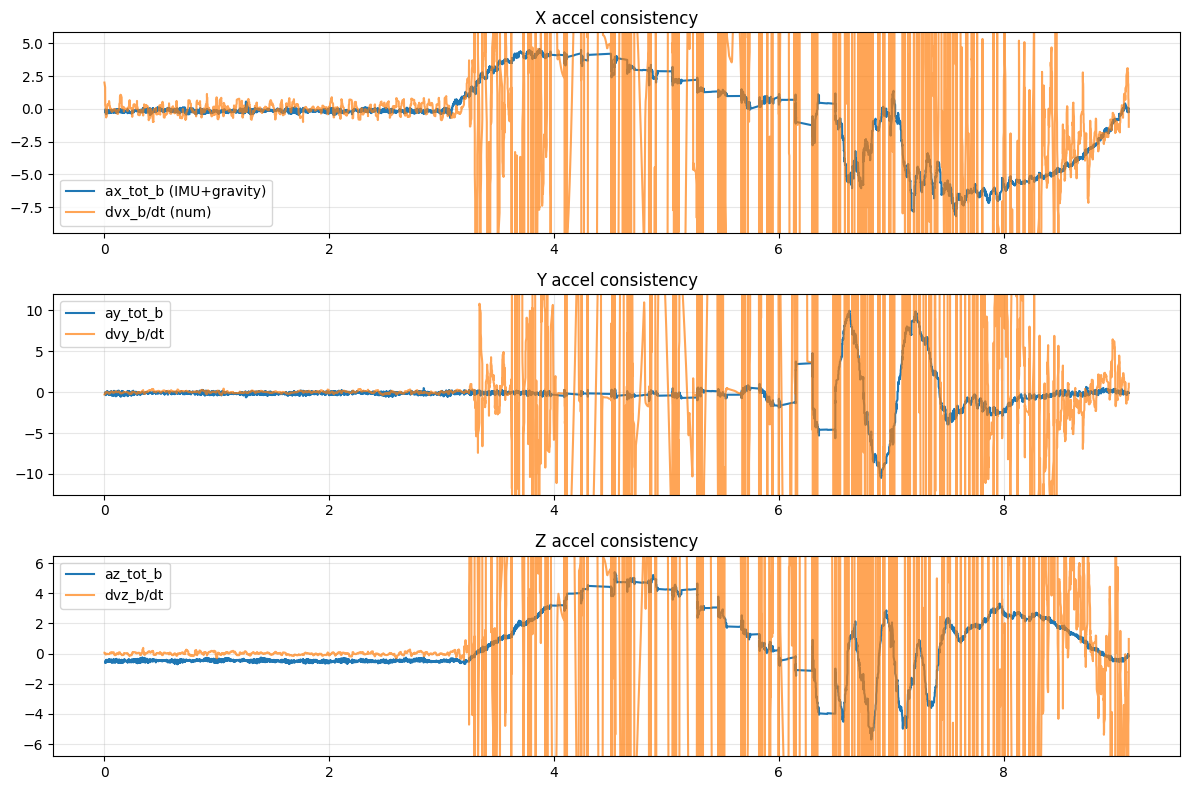

In [82]:
# Compare IMU-derived total acceleration vs derivative of velocity
# They should match in shape, sign, and magnitude if the physics is correct
# Some noise is acceptable, but large mismatches indicate problems with:
# - IMU interpretation (specific force + gravity)
# - Rotation/orientation estimation
# - Time alignment

plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
plt.plot(t_rel, combined["ax_tot_b"], label="ax_tot_b (IMU+gravity)")
plt.plot(t_rel, combined["dvx_b_dt"], label="dvx_b/dt (num)", alpha=0.7)
y_min, y_max = combined["ax_tot_b"].min(), combined["ax_tot_b"].max()
y_margin = (y_max - y_min) * 0.1
plt.ylim(y_min - y_margin, y_max + y_margin)
plt.legend(); plt.grid(True, alpha=0.3); plt.title("X accel consistency")

plt.subplot(3,1,2)
plt.plot(t_rel, combined["ay_tot_b"], label="ay_tot_b")
plt.plot(t_rel, combined["dvy_b_dt"], label="dvy_b/dt", alpha=0.7)
y_min, y_max = combined["ay_tot_b"].min(), combined["ay_tot_b"].max()
y_margin = (y_max - y_min) * 0.1
plt.ylim(y_min - y_margin, y_max + y_margin)
plt.legend(); plt.grid(True, alpha=0.3); plt.title("Y accel consistency")

plt.subplot(3,1,3)
plt.plot(t_rel, combined["az_tot_b"], label="az_tot_b")
plt.plot(t_rel, combined["dvz_b_dt"], label="dvz_b/dt", alpha=0.7)
y_min, y_max = combined["az_tot_b"].min(), combined["az_tot_b"].max()
y_margin = (y_max - y_min) * 0.1
plt.ylim(y_min - y_margin, y_max + y_margin)
plt.legend(); plt.grid(True, alpha=0.3); plt.title("Z accel consistency")

plt.tight_layout()
plt.show()

## 10. Thrust Model from RPM

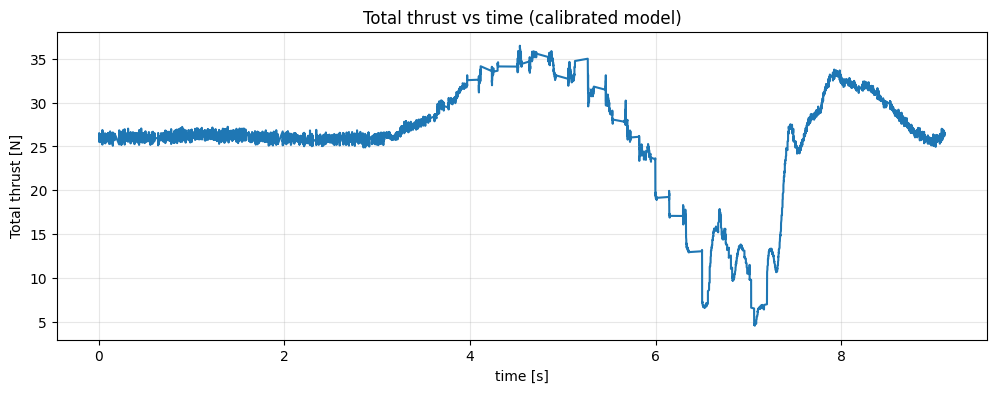

In [83]:
# Thrust model from RPM (calibrated)
#
# Calibrated thrust model: T = 5.15e-8 * RPM^2 - 0.09e-3 * RPM

def thrust_from_rpm_per_motor(rpm: np.ndarray) -> np.ndarray:
    """
    Map per-motor RPM to thrust [N].
    Calibrated model: T = 5.15e-8 * RPM^2 - 0.09e-3 * RPM
    """
    return 5.15e-8 * rpm**2 - 0.09e-3 * rpm

# Total thrust (assume average RPM ~ average per motor)
rpm_avg = combined["rpm_avg"].to_numpy()
T_per_motor = thrust_from_rpm_per_motor(rpm_avg)
T_total = n_motors * T_per_motor

combined["T_total"] = T_total

plt.figure(figsize=(12, 4))
plt.plot(t_rel, combined["T_total"])
plt.xlabel("time [s]")
plt.ylabel("Total thrust [N]")
plt.title("Total thrust vs time (calibrated model)")
plt.grid(True, alpha=0.3)
plt.show()


## 10a. Thrust Model Correction Using Hover Data

In [84]:
# Quick thrust model calibration using hover data
# Use hover data to compute a multiplicative correction factor
#
# Strategy: In hover, F_sum_z should equal thrust (no aerodynamic forces)
# So we can compute: alpha = mean(F_sum_z) / mean(T_model)

# Toggle thrust correction on/off
USE_THRUST_CORRECTION = False  # Set to False to use original uncorrected thrust model

# First, we need to compute V_b to identify hover condition
V_b_temp = np.linalg.norm(combined[["vx_b", "vy_b", "vz_b"]].to_numpy(), axis=1)

# Get time array for hover identification
t = combined["t"].to_numpy()
t_max = t.max()

# Define hover condition: last 1 second + low speed
hover_threshold = 0.5  # m/s
mask_last_1s = t >= (t_max - 1.0)
mask_hover_calib = (V_b_temp < hover_threshold) & mask_last_1s

print(f"Hover samples for thrust calibration: {mask_hover_calib.sum()} / {len(combined)}")

if USE_THRUST_CORRECTION and mask_hover_calib.sum() > 0:
    # Compute specific force z-component in hover
    f_z_hover = combined.loc[mask_hover_calib, "az_b"].to_numpy()
    F_sum_z_hover = mass * f_z_hover  # Total non-gravitational force in z
    T_model_hover = combined.loc[mask_hover_calib, "T_total"].to_numpy()
    
    # Compute correction factor
    alpha = np.mean(F_sum_z_hover) / np.mean(T_model_hover)
    
    print(f"\n✓ THRUST CORRECTION ENABLED")
    print(f"Thrust model correction:")
    print(f"  Mean F_sum_z (hover): {np.mean(F_sum_z_hover):.3f} N")
    print(f"  Mean T_model (hover): {np.mean(T_model_hover):.3f} N")
    print(f"  Correction factor α:  {alpha:.4f}")
    print(f"  → T_corrected = {alpha:.4f} × T_model")
    
    # Apply correction
    combined["T_total_corr"] = alpha * combined["T_total"]
    
    # Visualize correction
    plt.figure(figsize=(12, 6))
    
    plt.subplot(2,1,1)
    plt.plot(t_rel, combined["T_total"], label="T_total (original)", alpha=0.7)
    plt.plot(t_rel, combined["T_total_corr"], label="T_total_corr (corrected)", alpha=0.7)
    plt.xlabel("time [s]")
    plt.ylabel("Total thrust [N]")
    plt.title("Thrust correction: original vs corrected")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2,1,2)
    diff = combined["T_total_corr"] - combined["T_total"]
    plt.plot(t_rel, diff)
    plt.xlabel("time [s]")
    plt.ylabel("Thrust difference [N]")
    plt.title(f"Correction magnitude: α={alpha:.4f} → Δ = {diff.mean():.3f} ± {diff.std():.3f} N")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    if not USE_THRUST_CORRECTION:
        print("⚠️ THRUST CORRECTION DISABLED - Using original thrust model")
    else:
        print("⚠️ No hover samples found. Using uncorrected thrust model.")
    combined["T_total_corr"] = combined["T_total"]
    alpha = 1.0


Hover samples for thrust calibration: 1192 / 23584
⚠️ THRUST CORRECTION DISABLED - Using original thrust model


## 11. Aerodynamic Force in Body Frame (Correct)


In [85]:
# Aerodynamic force in body frame (correct)
#
# IMU specific force f_b = a_b - g_b  (already ax_b, ay_b, az_b)
# We use the specific force directly, not the total acceleration.
# Now using the corrected thrust model T_total_corr instead of T_total

f_b = np.vstack([
    combined["ax_b"].to_numpy(),
    combined["ay_b"].to_numpy(),
    combined["az_b"].to_numpy(),
]).T  # shape (N, 3)

# Total non-gravitational force in body frame
F_sum_b = mass * f_b  # m * f_b  = F_thrust + F_aero

# Thrust vector in body frame (using corrected thrust)
F_thrust_b = np.zeros_like(F_sum_b)
F_thrust_b[:, 2] = combined["T_total_corr"].to_numpy()  # thrust along +z_b

# Aerodynamic force = total non-grav - thrust
F_aero_b = F_sum_b - F_thrust_b

combined["F_aero_x_b"] = F_aero_b[:, 0]
combined["F_aero_y_b"] = F_aero_b[:, 1]
combined["F_aero_z_b"] = F_aero_b[:, 2]

# Store force components for analysis
combined["F_sum_x_b"] = F_sum_b[:, 0]
combined["F_sum_y_b"] = F_sum_b[:, 1]
combined["F_sum_z_b"] = F_sum_b[:, 2]

combined["F_thrust_x_b"] = F_thrust_b[:, 0]
combined["F_thrust_y_b"] = F_thrust_b[:, 1]
combined["F_thrust_z_b"] = F_thrust_b[:, 2]

print("Aerodynamic force (body frame) computed correctly from specific force.")

Aerodynamic force (body frame) computed correctly from specific force.


## 11a. Force Balance Check: Hover Condition

Last 2 seconds samples: 5174 / 23584
Hover samples in last 2s (V < 0.5 m/s): 1192 / 5174


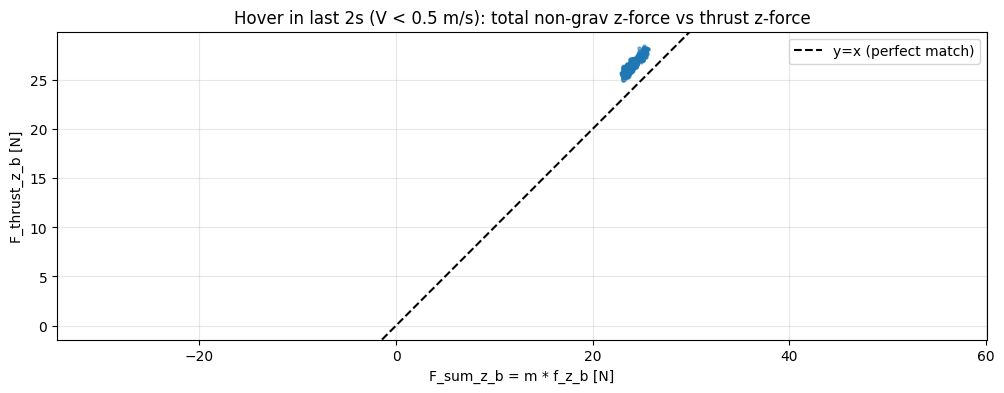


Hover statistics (last 2s):
  F_sum_z_b:    mean = 23.925 N, std = 0.647 N
  F_thrust_z_b: mean = 26.401 N, std = 0.719 N
  F_aero_z_b:   mean = -2.476 N, std = 0.275 N
  Difference (F_sum - F_thrust): mean = -2.476 N


In [86]:
# Force balance check: In hover (low speed), F_sum_b should approximately equal F_thrust_b
# because aerodynamic forces should be minimal
#
# Check: F_sum_b ≈ F_thrust_b when V_b < threshold
# Use only the last 2 seconds of data

V_b = np.linalg.norm(combined[["vx_b", "vy_b", "vz_b"]].to_numpy(), axis=1)
combined["V_b"] = V_b

# Get time array
t = combined["t"].to_numpy()
t_max = t.max()

# Define hover condition: last 2 seconds + low speed
hover_threshold = 0.5  # m/s
mask_last_2s = t >= (t_max - 2.0)
mask_hover = (V_b < hover_threshold) & mask_last_2s

print(f"Last 2 seconds samples: {mask_last_2s.sum()} / {len(combined)}")
print(f"Hover samples in last 2s (V < {hover_threshold} m/s): {mask_hover.sum()} / {mask_last_2s.sum()}")

# Plot: Total non-gravitational z-force vs thrust z-force during hover
plt.figure(figsize=(12,4))
plt.scatter(F_sum_b[mask_hover, 2], F_thrust_b[mask_hover, 2], s=5, alpha=0.5)
plt.xlabel("F_sum_z_b = m * f_z_b [N]")
plt.ylabel("F_thrust_z_b [N]")
plt.title(f"Hover in last 2s (V < {hover_threshold} m/s): total non-grav z-force vs thrust z-force")
plt.grid(True, alpha=0.3)
plt.axline((0,0), slope=1, color="k", linestyle="--", label="y=x (perfect match)")
plt.legend()
plt.axis("equal")
plt.show()

# Statistics during hover (last 2s)
if mask_hover.sum() > 0:
    F_sum_z_hover = F_sum_b[mask_hover, 2]
    F_thrust_z_hover = F_thrust_b[mask_hover, 2]
    F_aero_z_hover = F_aero_b[mask_hover, 2]
    
    print(f"\nHover statistics (last 2s):")
    print(f"  F_sum_z_b:    mean = {F_sum_z_hover.mean():.3f} N, std = {F_sum_z_hover.std():.3f} N")
    print(f"  F_thrust_z_b: mean = {F_thrust_z_hover.mean():.3f} N, std = {F_thrust_z_hover.std():.3f} N")
    print(f"  F_aero_z_b:   mean = {F_aero_z_hover.mean():.3f} N, std = {F_aero_z_hover.std():.3f} N")
    print(f"  Difference (F_sum - F_thrust): mean = {(F_sum_z_hover - F_thrust_z_hover).mean():.3f} N")
else:
    print("⚠️ No hover samples found in last 2 seconds.")

## 11a2. Aerodynamic Force Magnitude During Hover

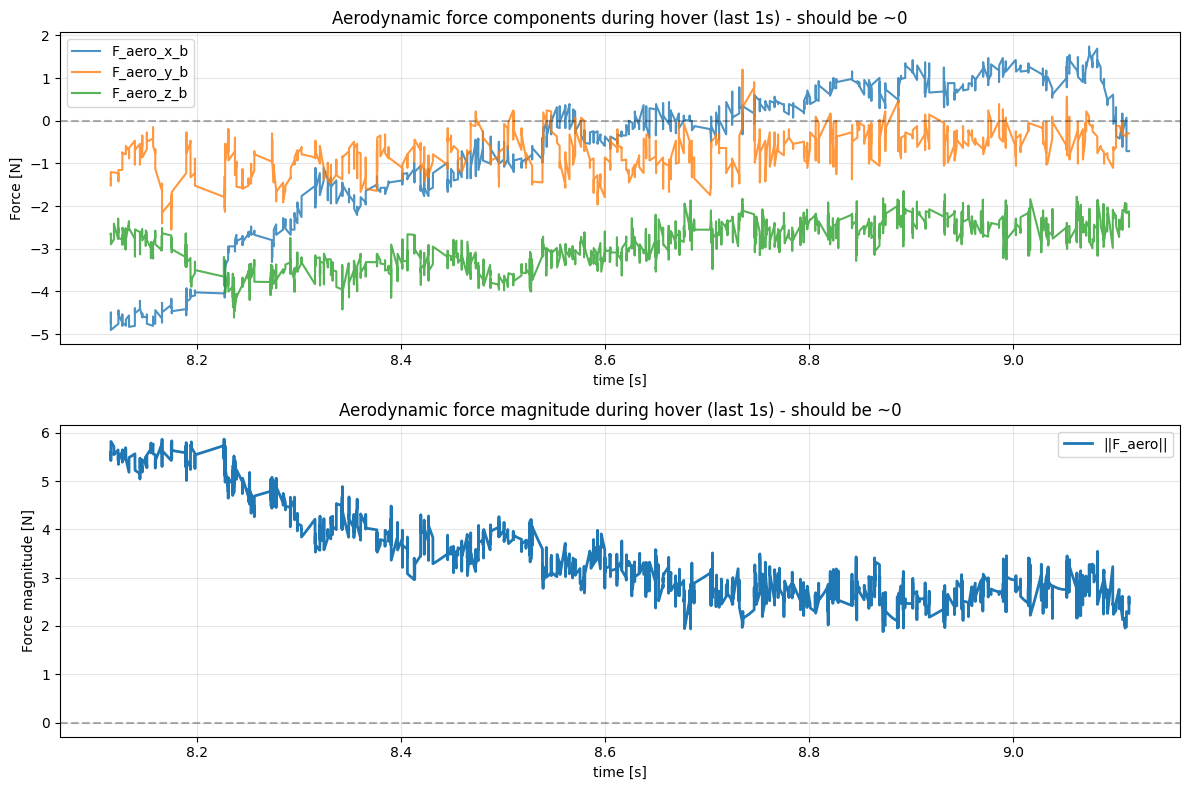


Aerodynamic force magnitude during hover (last 1s):
  Mean: 3.468 N
  Std:  0.987 N
  Max:  5.872 N
  Expected: close to 0 N (aerodynamic forces minimal in hover)


In [87]:
# Check aerodynamic force magnitude during hover (last 1s)
# It should be close to zero since aerodynamic forces are minimal at low speeds

t = combined["t"].to_numpy()
t_max = t.max()
mask_last_2s = t >= (t_max - 1.0)

t_rel = combined["t"] - combined["t"].min()
t_rel_hover = t_rel[mask_last_2s]

# Compute aerodynamic force magnitude
F_aero_mag = np.sqrt(
    combined["F_aero_x_b"]**2 + 
    combined["F_aero_y_b"]**2 + 
    combined["F_aero_z_b"]**2
)
combined["F_aero_mag"] = F_aero_mag

# Filter to only last 2 seconds
hover_data = combined[mask_last_2s].copy()
F_aero_x_hover = hover_data["F_aero_x_b"].to_numpy()
F_aero_y_hover = hover_data["F_aero_y_b"].to_numpy()
F_aero_z_hover = hover_data["F_aero_z_b"].to_numpy()
F_aero_mag_hover = hover_data["F_aero_mag"].to_numpy()

plt.figure(figsize=(12,8))

# Plot 1: All three components
plt.subplot(2,1,1)
plt.plot(t_rel_hover, F_aero_x_hover, label="F_aero_x_b", alpha=0.8)
plt.plot(t_rel_hover, F_aero_y_hover, label="F_aero_y_b", alpha=0.8)
plt.plot(t_rel_hover, F_aero_z_hover, label="F_aero_z_b", alpha=0.8)
plt.axhline(0, color='k', linestyle='--', alpha=0.3)
plt.xlabel("time [s]")
plt.ylabel("Force [N]")
plt.title("Aerodynamic force components during hover (last 1s) - should be ~0")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Magnitude
plt.subplot(2,1,2)
plt.plot(t_rel_hover, F_aero_mag_hover, label="||F_aero||", linewidth=2)
plt.axhline(0, color='k', linestyle='--', alpha=0.3)
plt.xlabel("time [s]")
plt.ylabel("Force magnitude [N]")
plt.title("Aerodynamic force magnitude during hover (last 1s) - should be ~0")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print(f"\nAerodynamic force magnitude during hover (last 1s):")
print(f"  Mean: {F_aero_mag_hover.mean():.3f} N")
print(f"  Std:  {F_aero_mag_hover.std():.3f} N")
print(f"  Max:  {F_aero_mag_hover.max():.3f} N")
print(f"  Expected: close to 0 N (aerodynamic forces minimal in hover)")

## 11b. Direction Sanity: Aerodynamic Force vs Velocity Alignment

Active flight samples (V > 1 m/s, ||F_aero|| > 1 N): 13006 / 23584


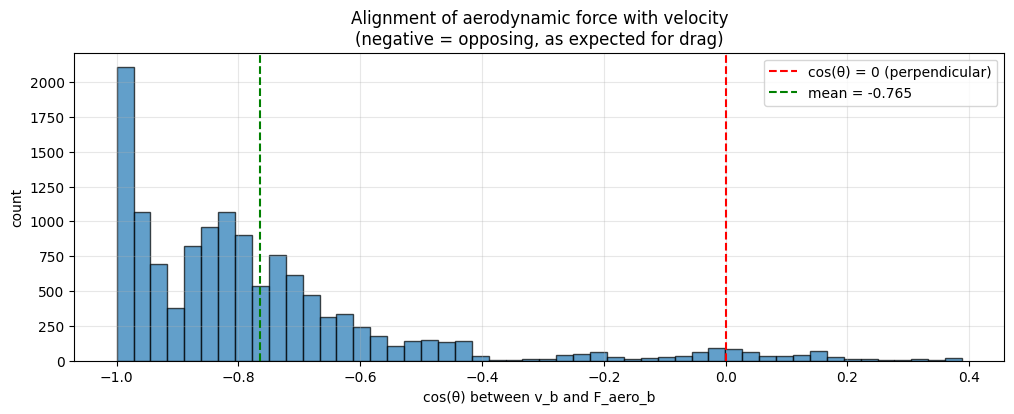


Cos(θ) statistics (active flight):
  Mean: -0.765
  Std:  0.244
  Median: -0.822
  % with cos(θ) < 0 (opposing): 96.9%


In [88]:
# Direction sanity check: In forward flight, drag should be mostly opposite to velocity
# Compute cosine of angle between F_aero and v_b
#
# Expected: cos(theta) < 0 (force opposes motion)
# If cos(theta) ≈ +1 or random → something is wrong

v_b_arr = combined[["vx_b", "vy_b", "vz_b"]].to_numpy()
F_a_arr = F_aero_b

v_norm = np.linalg.norm(v_b_arr, axis=1)
F_norm = np.linalg.norm(F_a_arr, axis=1)

# Filter out near-zero velocity and force to avoid noise
mask_active = (v_norm > 1.0) & (F_norm > 1.0)

# Compute cosine of angle: cos(θ) = (v · F) / (||v|| ||F||)
cos_theta = np.einsum("ij,ij->i", v_b_arr, F_a_arr) / (v_norm * F_norm + 1e-9)

print(f"Active flight samples (V > 1 m/s, ||F_aero|| > 1 N): {mask_active.sum()} / {len(combined)}")

if mask_active.sum() > 0:
    cos_theta_active = cos_theta[mask_active]
    
    plt.figure(figsize=(12,4))
    plt.hist(cos_theta_active, bins=50, alpha=0.7, edgecolor='black')
    plt.axvline(0, color='r', linestyle='--', label='cos(θ) = 0 (perpendicular)')
    plt.axvline(cos_theta_active.mean(), color='g', linestyle='--', 
                label=f'mean = {cos_theta_active.mean():.3f}')
    plt.xlabel("cos(θ) between v_b and F_aero_b")
    plt.ylabel("count")
    plt.title("Alignment of aerodynamic force with velocity\n(negative = opposing, as expected for drag)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"\nCos(θ) statistics (active flight):")
    print(f"  Mean: {cos_theta_active.mean():.3f}")
    print(f"  Std:  {cos_theta_active.std():.3f}")
    print(f"  Median: {np.median(cos_theta_active):.3f}")
    print(f"  % with cos(θ) < 0 (opposing): {100 * (cos_theta_active < 0).sum() / len(cos_theta_active):.1f}%")
else:
    print("⚠️ No active flight samples found. Adjust velocity/force thresholds.")

## 11b2. Proper Drag/Lift Decomposition

Drag and lift forces computed using proper projection.
Samples with non-zero velocity: 23584 / 23584


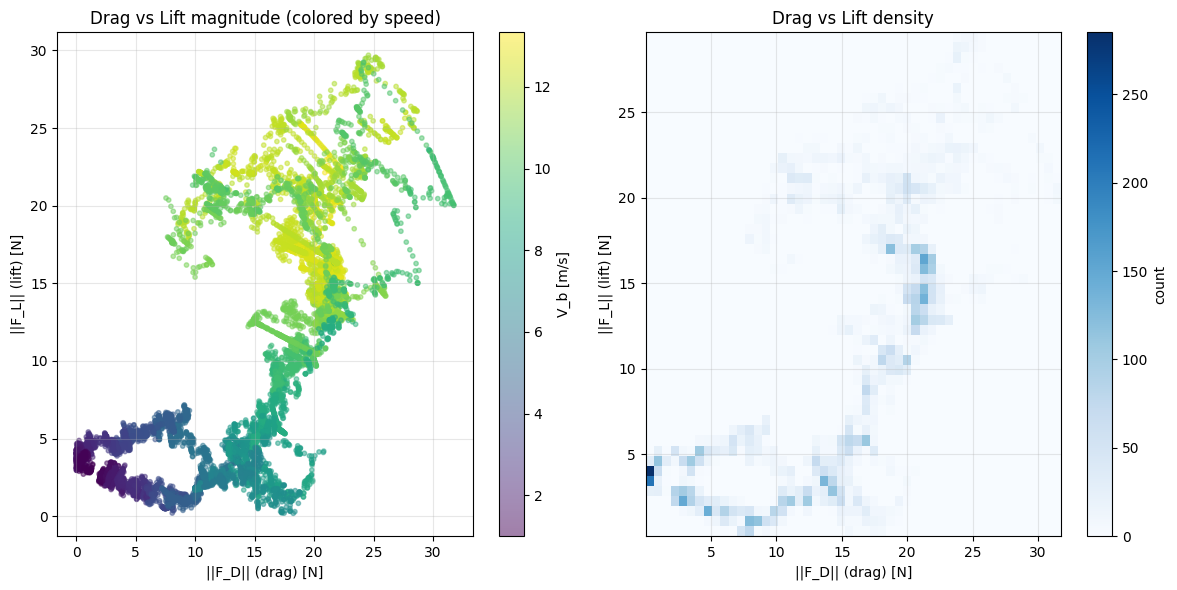

In [89]:
# Decompose aerodynamic force into drag and lift components
# Following the paper's definition:
#   F_D = (v · F_aero) / ||v||² * v  (projection onto velocity)
#   F_L = F_aero - F_D               (perpendicular to velocity)
#
# This is the proper decomposition, not the hack of assuming motion along x_b

v_b = combined[["vx_b", "vy_b", "vz_b"]].to_numpy()
F_a = F_aero_b

v_sq = np.sum(v_b**2, axis=1)
mask_nonzero = v_sq > 1e-6  # Avoid division by zero

# Initialize drag and lift arrays
F_D = np.zeros_like(F_a)
F_L = np.zeros_like(F_a)

# Compute drag and lift only where velocity is non-zero
v_b_nz = v_b[mask_nonzero]
F_a_nz = F_a[mask_nonzero]
v_sq_nz = v_sq[mask_nonzero]

# Drag coefficient: (v · F) / ||v||²
coeff = np.einsum("ij,ij->i", v_b_nz, F_a_nz) / v_sq_nz

# Drag force: parallel to velocity
F_D[mask_nonzero] = (coeff[:, None]) * v_b_nz

# Lift force: perpendicular to velocity
F_L[mask_nonzero] = F_a_nz - F_D[mask_nonzero]

# Store components in dataframe
combined["F_D_x_b"], combined["F_D_y_b"], combined["F_D_z_b"] = F_D.T
combined["F_L_x_b"], combined["F_L_y_b"], combined["F_L_z_b"] = F_L.T

# Compute magnitudes
combined["F_D_mag"] = np.linalg.norm(F_D, axis=1)
combined["F_L_mag"] = np.linalg.norm(F_L, axis=1)

print("Drag and lift forces computed using proper projection.")
print(f"Samples with non-zero velocity: {mask_nonzero.sum()} / {len(combined)}")

# Quick visualization: scatter of drag vs lift magnitude
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
mask_active = V_b > 1.0
plt.scatter(combined.loc[mask_active, "F_D_mag"], 
           combined.loc[mask_active, "F_L_mag"], 
           c=V_b[mask_active], s=10, alpha=0.5, cmap='viridis')
plt.colorbar(label='V_b [m/s]')
plt.xlabel("||F_D|| (drag) [N]")
plt.ylabel("||F_L|| (lift) [N]")
plt.title("Drag vs Lift magnitude (colored by speed)")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist2d(combined.loc[mask_active, "F_D_mag"], 
          combined.loc[mask_active, "F_L_mag"], 
          bins=50, cmap='Blues')
plt.colorbar(label='count')
plt.xlabel("||F_D|| (drag) [N]")
plt.ylabel("||F_L|| (lift) [N]")
plt.title("Drag vs Lift density")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 11c. Drag Scaling: Aerodynamic Force vs V²

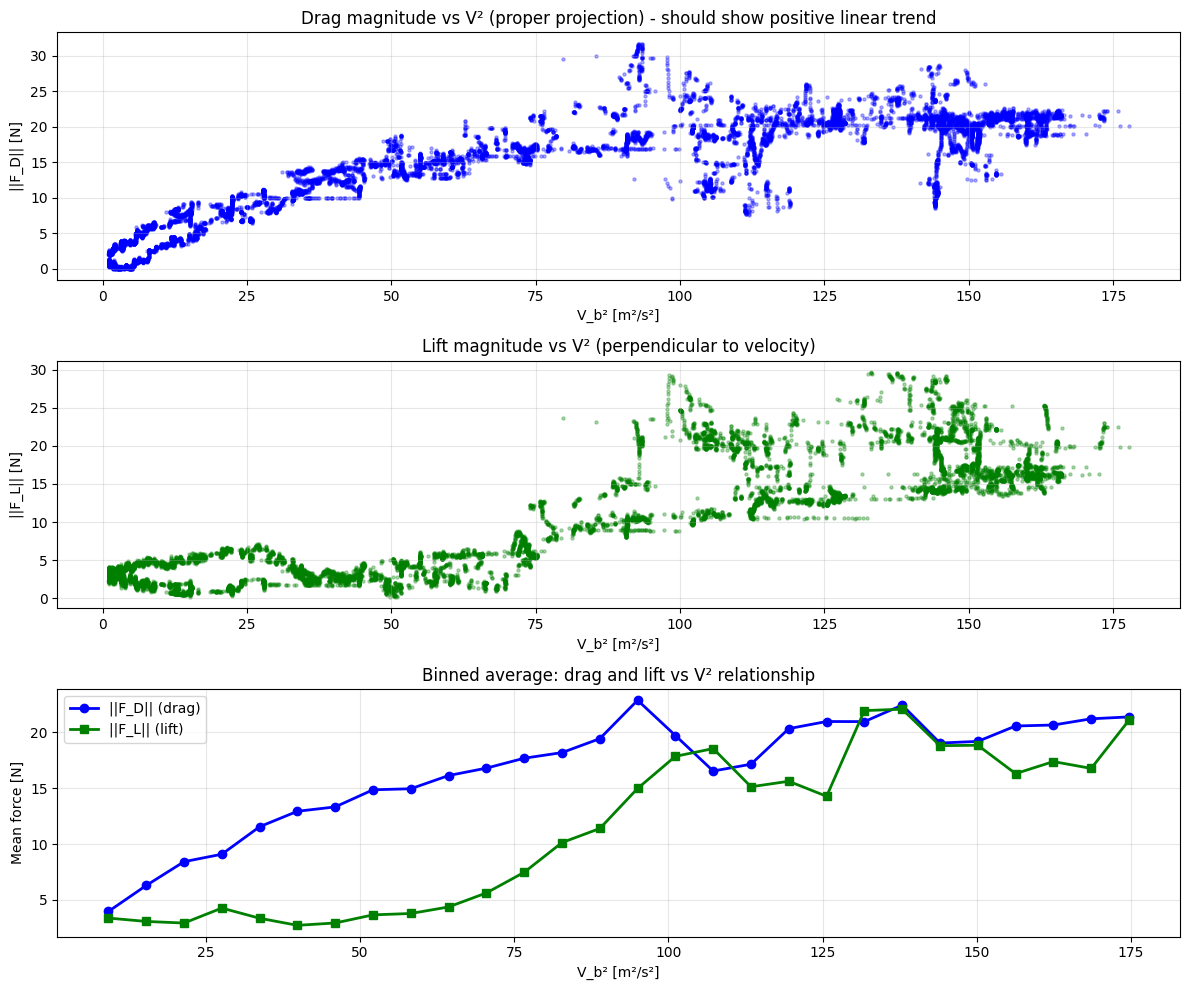

Expected: Drag shows clear positive linear trend with V²
Expected: Lift may show more complex behavior depending on pitch/AoA


In [90]:
# Drag scaling check: Properly computed drag should scale with V²
# This is the fundamental physics of drag: F_D = ½ ρ C_D A V²
#
# Expected: positive linear trend in drag magnitude vs V²
# Now using the proper drag force from projection, not the x-component hack

# Use properly computed drag magnitude
F_drag_mag_proper = combined["F_D_mag"].to_numpy()

plt.figure(figsize=(12,10))

# Plot 1: Drag magnitude vs V² (scatter)
plt.subplot(3,1,1)
mask_active = V_b > 1.0
plt.scatter(V_b[mask_active]**2, F_drag_mag_proper[mask_active], s=5, alpha=0.3, color='blue')
plt.xlabel("V_b² [m²/s²]")
plt.ylabel("||F_D|| [N]")
plt.title("Drag magnitude vs V² (proper projection) - should show positive linear trend")
plt.grid(True, alpha=0.3)

# Plot 2: Lift magnitude vs V²
plt.subplot(3,1,2)
F_lift_mag_proper = combined["F_L_mag"].to_numpy()
plt.scatter(V_b[mask_active]**2, F_lift_mag_proper[mask_active], s=5, alpha=0.3, color='green')
plt.xlabel("V_b² [m²/s²]")
plt.ylabel("||F_L|| [N]")
plt.title("Lift magnitude vs V² (perpendicular to velocity)")
plt.grid(True, alpha=0.3)

# Plot 3: Binned average to see trends more clearly
plt.subplot(3,1,3)
V2_bins = np.linspace(0, (V_b**2).max(), 30)
bin_centers = (V2_bins[:-1] + V2_bins[1:]) / 2
F_drag_binned = []
F_lift_binned = []

for i in range(len(V2_bins) - 1):
    mask_bin = (V_b**2 >= V2_bins[i]) & (V_b**2 < V2_bins[i+1])
    if mask_bin.sum() > 0:
        F_drag_binned.append(F_drag_mag_proper[mask_bin].mean())
        F_lift_binned.append(F_lift_mag_proper[mask_bin].mean())
    else:
        F_drag_binned.append(np.nan)
        F_lift_binned.append(np.nan)

plt.plot(bin_centers, F_drag_binned, 'o-', linewidth=2, markersize=6, label='||F_D|| (drag)', color='blue')
plt.plot(bin_centers, F_lift_binned, 's-', linewidth=2, markersize=6, label='||F_L|| (lift)', color='green')
plt.xlabel("V_b² [m²/s²]")
plt.ylabel("Mean force [N]")
plt.title("Binned average: drag and lift vs V² relationship")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Expected: Drag shows clear positive linear trend with V²")
print("Expected: Lift may show more complex behavior depending on pitch/AoA")

## 11c2. Attitude Angles: Roll, Pitch, Yaw Over Time

Roll, pitch, and yaw angles extracted from quaternions.


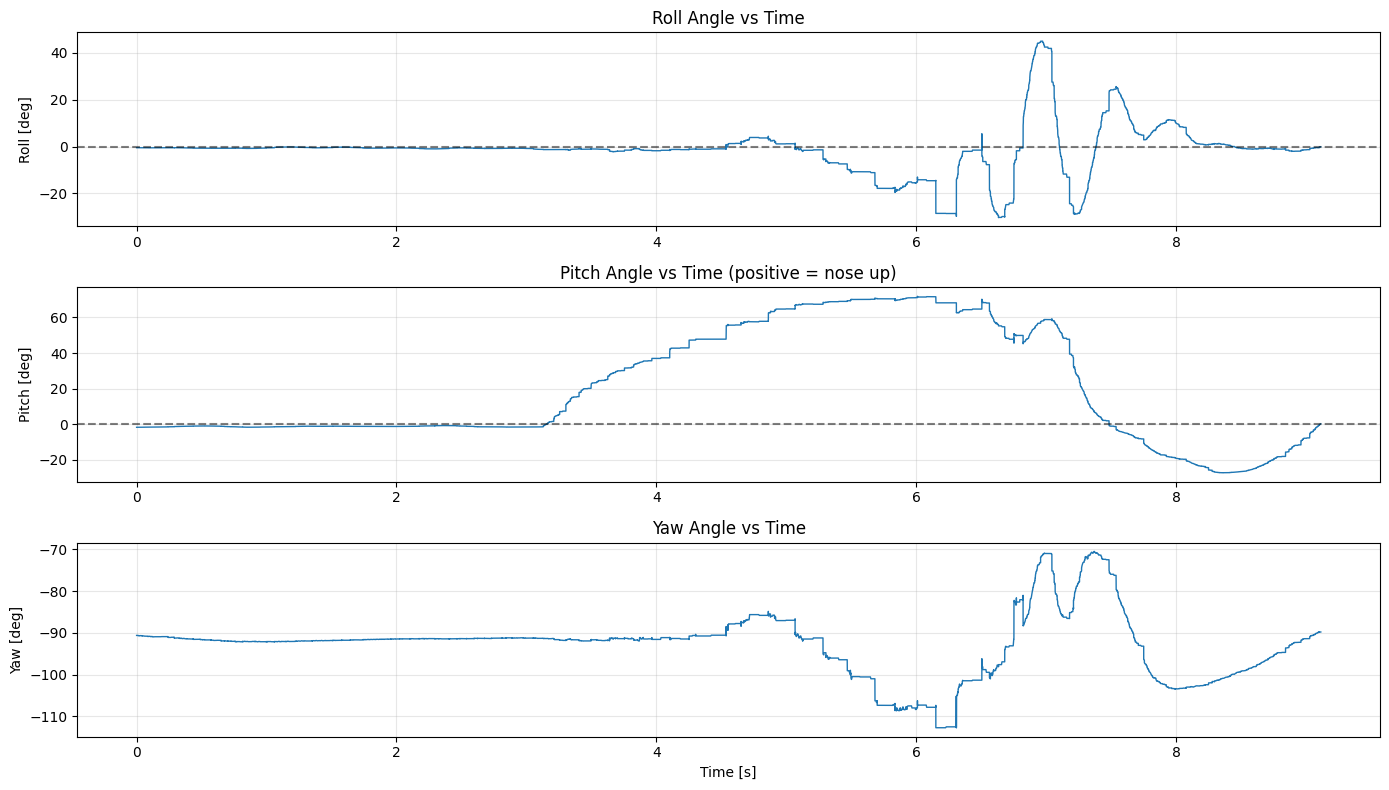


Attitude angle statistics:
  Roll:  min = -30.40°, max =  45.06°, mean =  -1.46°, std = 10.30°
  Pitch: min = -27.18°, max =  71.83°, mean =  20.20°, std = 32.00°
  Yaw:   min = -112.78°, max = -70.52°, mean = -92.86°, std =  7.50°


In [91]:
# Extract roll, pitch, and yaw angles from quaternion orientation
# These are Euler angles representing the aircraft attitude
#
# Roll:  rotation about x-axis (body frame tilt side-to-side)
# Pitch: rotation about y-axis (body frame tilt forward-back) 
# Yaw:   rotation about z-axis (body frame heading)

from transforms3d.euler import quat2euler

roll_list = []
pitch_list = []
yaw_list = []

for _, row in combined.iterrows():
    quat = [row["qw_w"], row["qx_w"], row["qy_w"], row["qz_w"]]  # w, x, y, z order
    # Extract Euler angles (roll, pitch, yaw) using 'sxyz' convention
    roll, pitch, yaw = quat2euler(quat, axes='sxyz')
    roll_list.append(roll)
    pitch_list.append(pitch)
    yaw_list.append(yaw)

combined["roll_rad"] = np.array(roll_list)
combined["roll_deg"] = combined["roll_rad"] * 180 / np.pi

combined["pitch_rad"] = np.array(pitch_list)
combined["pitch_deg"] = combined["pitch_rad"] * 180 / np.pi

combined["yaw_rad"] = np.array(yaw_list)
combined["yaw_deg"] = combined["yaw_rad"] * 180 / np.pi

print("Roll, pitch, and yaw angles extracted from quaternions.")

# Visualization: Attitude angles over time
t_rel = combined["t"] - combined["t"].min()

plt.figure(figsize=(14, 8))

plt.subplot(3, 1, 1)
plt.plot(t_rel, combined["roll_deg"], linewidth=1)
plt.ylabel("Roll [deg]")
plt.title("Roll Angle vs Time")
plt.grid(True, alpha=0.3)
plt.axhline(0, color='k', linestyle='--', alpha=0.5)

plt.subplot(3, 1, 2)
plt.plot(t_rel, combined["pitch_deg"], linewidth=1)
plt.ylabel("Pitch [deg]")
plt.title("Pitch Angle vs Time (positive = nose up)")
plt.grid(True, alpha=0.3)
plt.axhline(0, color='k', linestyle='--', alpha=0.5)

plt.subplot(3, 1, 3)
plt.plot(t_rel, combined["yaw_deg"], linewidth=1)
plt.xlabel("Time [s]")
plt.ylabel("Yaw [deg]")
plt.title("Yaw Angle vs Time")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nAttitude angle statistics:")
print(f"  Roll:  min = {combined['roll_deg'].min():6.2f}°, max = {combined['roll_deg'].max():6.2f}°, "
      f"mean = {combined['roll_deg'].mean():6.2f}°, std = {combined['roll_deg'].std():5.2f}°")
print(f"  Pitch: min = {combined['pitch_deg'].min():6.2f}°, max = {combined['pitch_deg'].max():6.2f}°, "
      f"mean = {combined['pitch_deg'].mean():6.2f}°, std = {combined['pitch_deg'].std():5.2f}°")
print(f"  Yaw:   min = {combined['yaw_deg'].min():6.2f}°, max = {combined['yaw_deg'].max():6.2f}°, "
      f"mean = {combined['yaw_deg'].mean():6.2f}°, std = {combined['yaw_deg'].std():5.2f}°")


## 11d. Vertical Balance: Aerodynamic Force vs Pitch

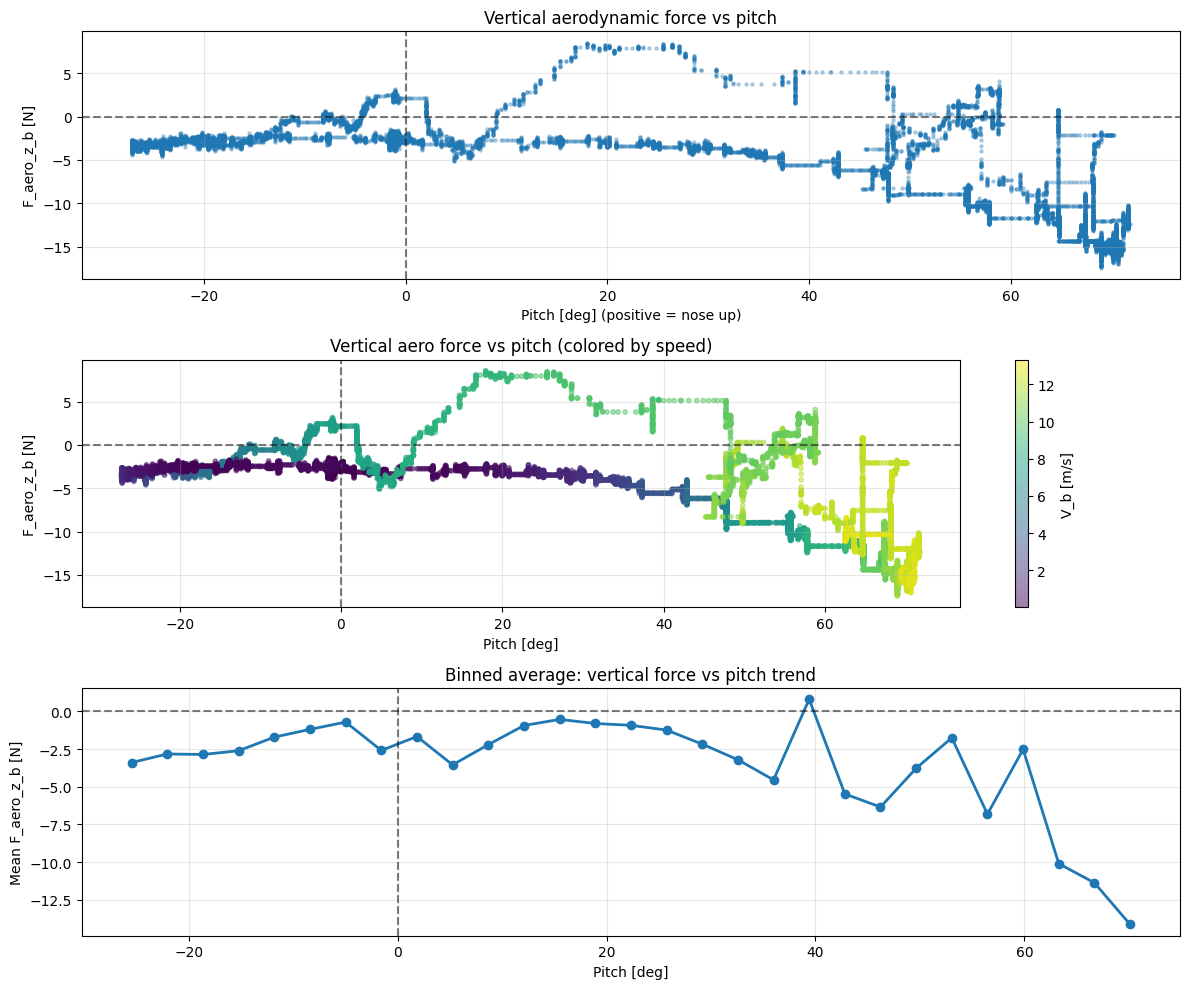

Pitch range: [-27.2, 71.8] deg
Expected: As pitch decreases (nose down) and speed increases, vertical lift should increase


In [92]:
# Vertical balance check: In forward flight with pitch, wings generate lift
# As pitch nose-down increases (more forward flight), vertical aerodynamic force should increase
#
# Pitch angle already computed in section 11c2

plt.figure(figsize=(12,10))

# Plot 1: F_aero_z vs pitch (all data)
plt.subplot(3,1,1)
plt.scatter(combined["pitch_deg"], combined["F_aero_z_b"], s=5, alpha=0.3)
plt.xlabel("Pitch [deg] (positive = nose up)")
plt.ylabel("F_aero_z_b [N]")
plt.title("Vertical aerodynamic force vs pitch")
plt.grid(True, alpha=0.3)
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.axvline(0, color='k', linestyle='--', alpha=0.5)

# Plot 2: Color by velocity to see speed effect
plt.subplot(3,1,2)
scatter = plt.scatter(combined["pitch_deg"], combined["F_aero_z_b"], 
                      c=V_b, s=10, alpha=0.5, cmap='viridis')
plt.colorbar(scatter, label='V_b [m/s]')
plt.xlabel("Pitch [deg]")
plt.ylabel("F_aero_z_b [N]")
plt.title("Vertical aero force vs pitch (colored by speed)")
plt.grid(True, alpha=0.3)
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.axvline(0, color='k', linestyle='--', alpha=0.5)

# Plot 3: Binned average vs pitch
plt.subplot(3,1,3)
pitch_bins = np.linspace(combined["pitch_deg"].min(), combined["pitch_deg"].max(), 30)
pitch_centers = (pitch_bins[:-1] + pitch_bins[1:]) / 2
F_aero_z_binned = []

for i in range(len(pitch_bins) - 1):
    mask_bin = (combined["pitch_deg"] >= pitch_bins[i]) & (combined["pitch_deg"] < pitch_bins[i+1])
    if mask_bin.sum() > 0:
        F_aero_z_binned.append(combined["F_aero_z_b"][mask_bin].mean())
    else:
        F_aero_z_binned.append(np.nan)

plt.plot(pitch_centers, F_aero_z_binned, 'o-', linewidth=2, markersize=6)
plt.xlabel("Pitch [deg]")
plt.ylabel("Mean F_aero_z_b [N]")
plt.title("Binned average: vertical force vs pitch trend")
plt.grid(True, alpha=0.3)
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.axvline(0, color='k', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Pitch range: [{combined['pitch_deg'].min():.1f}, {combined['pitch_deg'].max():.1f}] deg")
print("Expected: As pitch decreases (nose down) and speed increases, vertical lift should increase")

## 11d2. Lift Magnitude vs Pitch and Speed

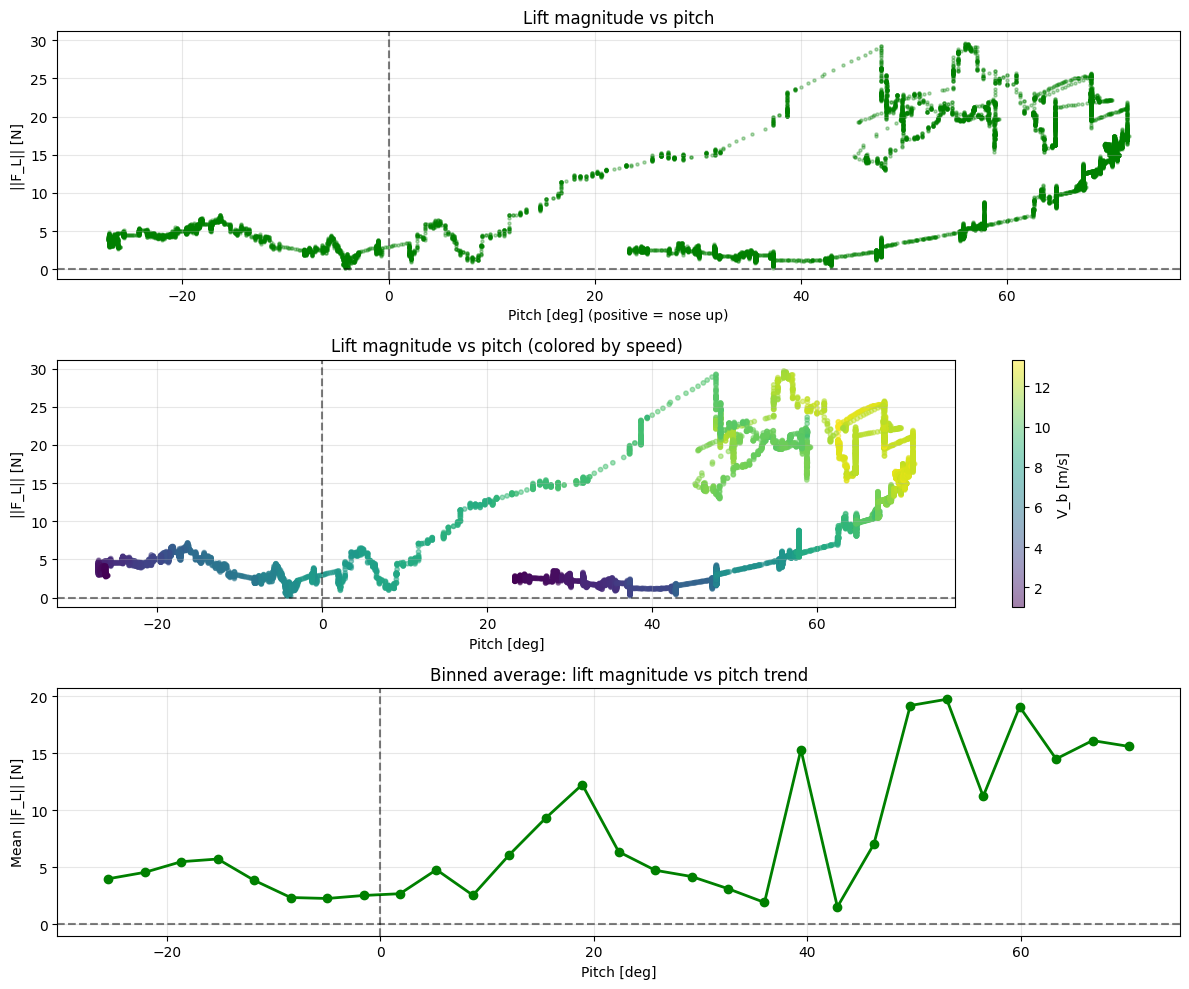

Expected: Lift increases with forward speed (nose down pitch) due to wing effect


In [93]:
# Lift behavior analysis: properly computed lift vs pitch and speed
# Wing lift should increase with speed and depend on pitch/angle of attack
#
# Now using the proper lift force perpendicular to velocity

plt.figure(figsize=(12,10))

# Plot 1: Lift magnitude vs pitch (all data)
plt.subplot(3,1,1)
mask_active = V_b > 1.0
plt.scatter(combined.loc[mask_active, "pitch_deg"], 
           combined.loc[mask_active, "F_L_mag"], 
           s=5, alpha=0.3, color='green')
plt.xlabel("Pitch [deg] (positive = nose up)")
plt.ylabel("||F_L|| [N]")
plt.title("Lift magnitude vs pitch")
plt.grid(True, alpha=0.3)
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.axvline(0, color='k', linestyle='--', alpha=0.5)

# Plot 2: Lift magnitude vs pitch, colored by speed
plt.subplot(3,1,2)
scatter = plt.scatter(combined.loc[mask_active, "pitch_deg"], 
                      combined.loc[mask_active, "F_L_mag"], 
                      c=V_b[mask_active], s=10, alpha=0.5, cmap='viridis')
plt.colorbar(scatter, label='V_b [m/s]')
plt.xlabel("Pitch [deg]")
plt.ylabel("||F_L|| [N]")
plt.title("Lift magnitude vs pitch (colored by speed)")
plt.grid(True, alpha=0.3)
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.axvline(0, color='k', linestyle='--', alpha=0.5)

# Plot 3: Binned average vs pitch
plt.subplot(3,1,3)
pitch_bins = np.linspace(combined["pitch_deg"].min(), combined["pitch_deg"].max(), 30)
pitch_centers = (pitch_bins[:-1] + pitch_bins[1:]) / 2
F_lift_mag_binned = []

for i in range(len(pitch_bins) - 1):
    mask_bin = (combined["pitch_deg"] >= pitch_bins[i]) & (combined["pitch_deg"] < pitch_bins[i+1]) & mask_active
    if mask_bin.sum() > 0:
        F_lift_mag_binned.append(combined.loc[mask_bin, "F_L_mag"].mean())
    else:
        F_lift_mag_binned.append(np.nan)

plt.plot(pitch_centers, F_lift_mag_binned, 'o-', linewidth=2, markersize=6, color='green')
plt.xlabel("Pitch [deg]")
plt.ylabel("Mean ||F_L|| [N]")
plt.title("Binned average: lift magnitude vs pitch trend")
plt.grid(True, alpha=0.3)
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.axvline(0, color='k', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("Expected: Lift increases with forward speed (nose down pitch) due to wing effect")

## 11e. Signal Quality: Noise Level Assessment

SIGNAL QUALITY ASSESSMENT: Aerodynamic Force Statistics

Hover (V < 0.5 m/s) - 9964 samples:
----------------------------------------------------------------------
  F_aero_x_b  : mean =   0.237 N, std =  0.431 N, SNR =  0.55
  F_aero_y_b  : mean =  -0.601 N, std =  0.333 N, SNR =  1.80
  F_aero_z_b  : mean =  -2.692 N, std =  0.358 N, SNR =  7.52
  ||F_aero||  : mean =   2.819 N, std =  0.375 N

Cruise (7.5 < V < 8.5 m/s) - 769 samples:
----------------------------------------------------------------------
  F_aero_x_b  : mean = -14.642 N, std =  1.864 N, SNR =  7.85
  F_aero_y_b  : mean =   2.307 N, std =  2.788 N, SNR =  0.83
  F_aero_z_b  : mean =  -4.604 N, std =  5.151 N, SNR =  0.89
  ||F_aero||  : mean =  16.616 N, std =  1.591 N

All data - 23584 samples:
----------------------------------------------------------------------
  F_aero_x_b  : mean =  -8.186 N, std =  9.938 N, SNR =  0.82
  F_aero_y_b  : mean =  -0.585 N, std =  4.016 N, SNR =  0.15
  F_aero_z_b  : mean =  -4.826

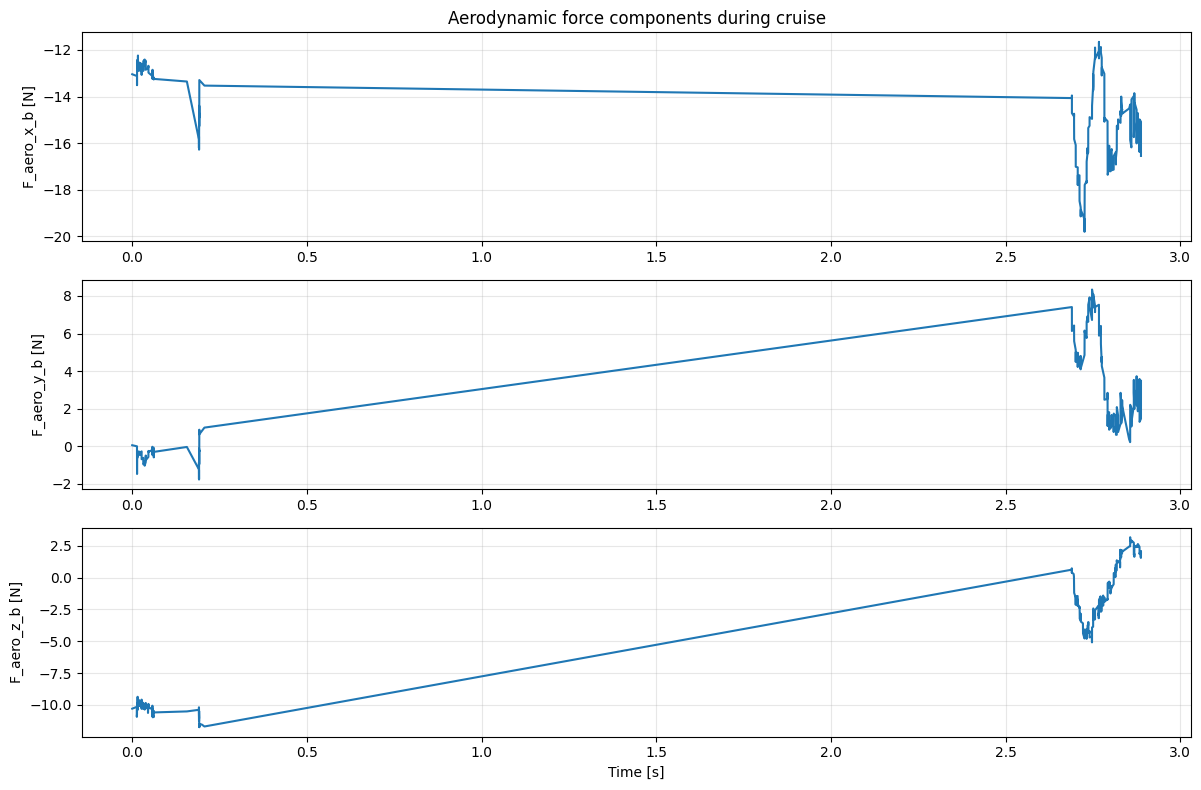

In [94]:
# Noise level assessment: Check signal-to-noise ratio in different flight regimes
# If std is comparable to mean, the signal is dominated by noise
#
# Compare:
# - Hover (low speed): F_aero should be small with low noise
# - Cruise (steady forward flight): F_aero should be consistent with reasonable std

print("="*70)
print("SIGNAL QUALITY ASSESSMENT: Aerodynamic Force Statistics")
print("="*70)

# Define flight regimes
mask_hover = V_b < 0.5
mask_cruise = (V_b > 7.5) & (V_b < 8.5)  # 8 m/s circle
mask_all = np.ones(len(combined), dtype=bool)

regimes = {
    "Hover (V < 0.5 m/s)": mask_hover,
    "Cruise (7.5 < V < 8.5 m/s)": mask_cruise,
    "All data": mask_all
}

for regime_name, mask in regimes.items():
    if mask.sum() == 0:
        print(f"\n{regime_name}: No samples found")
        continue
    
    print(f"\n{regime_name} - {mask.sum()} samples:")
    print("-" * 70)
    
    for component in ["F_aero_x_b", "F_aero_y_b", "F_aero_z_b"]:
        data = combined.loc[mask, component]
        mean_val = data.mean()
        std_val = data.std()
        snr = abs(mean_val) / (std_val + 1e-9)  # signal-to-noise ratio
        
        print(f"  {component:12s}: mean = {mean_val:7.3f} N, std = {std_val:6.3f} N, SNR = {snr:5.2f}")
    
    # Overall magnitude
    F_mag = np.sqrt(
        combined.loc[mask, "F_aero_x_b"]**2 + 
        combined.loc[mask, "F_aero_y_b"]**2 + 
        combined.loc[mask, "F_aero_z_b"]**2
    )
    print(f"  {'||F_aero||':12s}: mean = {F_mag.mean():7.3f} N, std = {F_mag.std():6.3f} N")

print("\n" + "="*70)
print("INTERPRETATION:")
print("  - SNR > 3: Good signal quality")
print("  - SNR 1-3: Marginal, signal visible but noisy")
print("  - SNR < 1: Poor, noise dominates signal")
print("="*70)

# Visualization: Time series in different regimes
if mask_cruise.sum() > 0:
    t_cruise = combined.loc[mask_cruise, "t"].to_numpy()
    t_cruise_rel = t_cruise - t_cruise.min()
    
    plt.figure(figsize=(12, 8))
    
    plt.subplot(3, 1, 1)
    plt.plot(t_cruise_rel, combined.loc[mask_cruise, "F_aero_x_b"])
    plt.ylabel("F_aero_x_b [N]")
    plt.title("Aerodynamic force components during cruise")
    plt.grid(True, alpha=0.3)
    
    plt.subplot(3, 1, 2)
    plt.plot(t_cruise_rel, combined.loc[mask_cruise, "F_aero_y_b"])
    plt.ylabel("F_aero_y_b [N]")
    plt.grid(True, alpha=0.3)
    
    plt.subplot(3, 1, 3)
    plt.plot(t_cruise_rel, combined.loc[mask_cruise, "F_aero_z_b"])
    plt.ylabel("F_aero_z_b [N]")
    plt.xlabel("Time [s]")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 12. Visualization: Aerodynamic Force vs Forward Speed

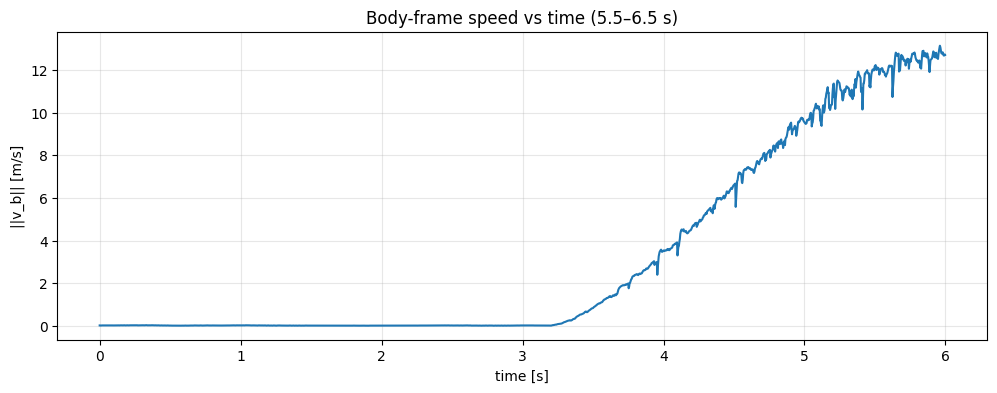

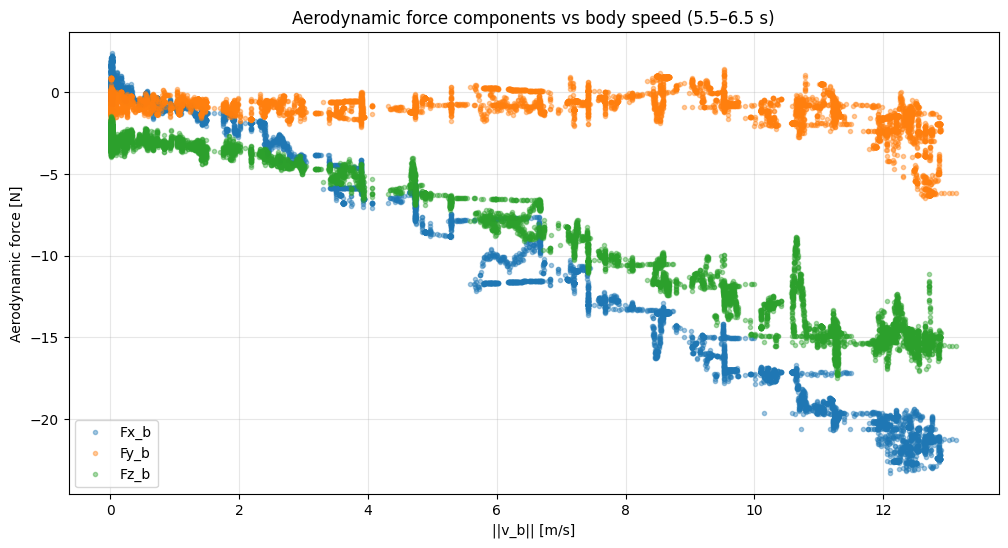

In [95]:
# Quick visualization of aerodynamic force vs forward speed (time window only)

# Approximate airspeed as magnitude of body-frame velocity (ignores wind)
V_b = np.linalg.norm(v_b, axis=1)
combined["V_b"] = V_b

# ---- NEW: select time window [5.5, 6.5] s ----
t_rel = combined["t"] - combined["t"].min()
mask = (t_rel >= 0) & (t_rel <= 6)

t_rel_win = t_rel[mask]
V_b_win = V_b[mask]
Fx_win = combined.loc[mask, "F_aero_x_b"]
Fy_win = combined.loc[mask, "F_aero_y_b"]
Fz_win = combined.loc[mask, "F_aero_z_b"]

# Plot speed vs time in that window
plt.figure(figsize=(12, 4))
plt.plot(t_rel_win, V_b_win)
plt.xlabel("time [s]")
plt.ylabel("||v_b|| [m/s]")
plt.title("Body-frame speed vs time (5.5–6.5 s)")
plt.grid(True, alpha=0.3)
plt.show()

# Plot forces vs speed (only samples in window)
plt.figure(figsize=(12, 6))
plt.plot(V_b_win, Fx_win, ".", alpha=0.4, label="Fx_b")
plt.plot(V_b_win, Fy_win, ".", alpha=0.4, label="Fy_b")
plt.plot(V_b_win, Fz_win, ".", alpha=0.4, label="Fz_b")
plt.xlabel("||v_b|| [m/s]")
plt.ylabel("Aerodynamic force [N]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Aerodynamic force components vs body speed (5.5–6.5 s)")
plt.show()


Samples: 15455


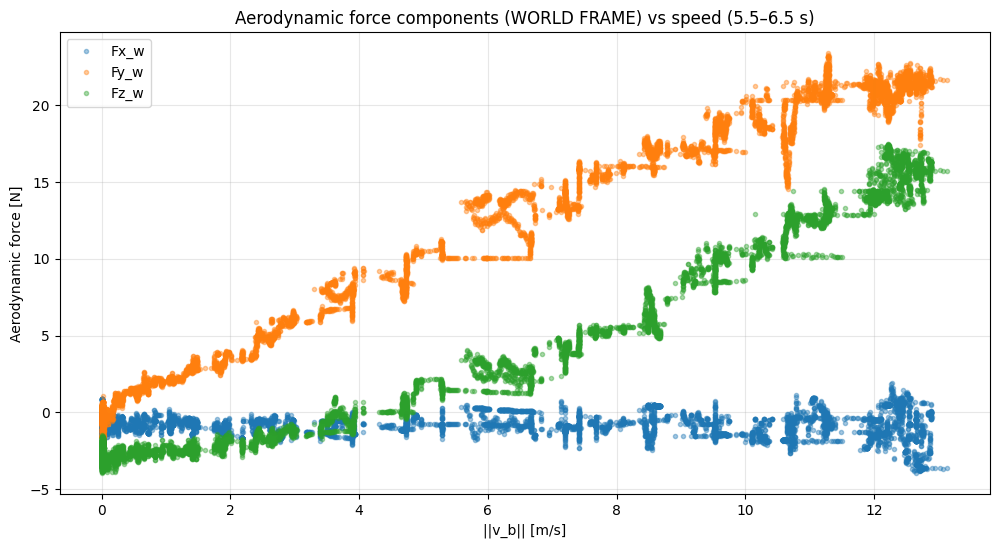

In [103]:
# Time window
t_rel = combined["t"] - combined["t"].min()
mask = (t_rel >= 0) & (t_rel <= 6.0)
print("Samples:", mask.sum())

# Select WORLD-FRAME aerodynamic forces
Fx_w_win = combined.loc[mask, "F_aero_x_w"].to_numpy()
Fy_w_win = combined.loc[mask, "F_aero_y_w"].to_numpy()
Fz_w_win = combined.loc[mask, "F_aero_z_w"].to_numpy()

# Body-frame speed magnitude (you already computed it)
V_b_win = V_b[mask]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(V_b_win, Fx_w_win, ".", alpha=0.4, label="Fx_w")
plt.plot(V_b_win, Fy_w_win, ".", alpha=0.4, label="Fy_w")
plt.plot(V_b_win, Fz_w_win, ".", alpha=0.4, label="Fz_w")

plt.xlabel("||v_b|| [m/s]")
plt.ylabel("Aerodynamic force [N]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Aerodynamic force components (WORLD FRAME) vs speed (5.5–6.5 s)")
plt.show()


In [96]:
## 11f. Forces in world frame

# Body-frame forces as arrays
F_thrust_b = combined[["F_thrust_x_b", "F_thrust_y_b", "F_thrust_z_b"]].to_numpy()
F_aero_b   = combined[["F_aero_x_b",   "F_aero_y_b",   "F_aero_z_b"]].to_numpy()
F_sum_b    = combined[["F_sum_x_b",    "F_sum_y_b",    "F_sum_z_b"]].to_numpy()

N = len(combined)

F_thrust_w = np.zeros_like(F_thrust_b)
F_aero_w   = np.zeros_like(F_aero_b)
F_sum_w    = np.zeros_like(F_sum_b)
F_g_w      = np.zeros_like(F_sum_b)  # same everywhere, but store for completeness

g_world_vec = np.array([0.0, 0.0, -mass * g])

for i, row in combined.iterrows():
    # world -> body
    R_wb = R_world_to_body(row["qw_w"], row["qx_w"], row["qy_w"], row["qz_w"])
    # body -> world
    R_bw = R_wb.T

    F_thrust_w[i, :] = R_bw @ F_thrust_b[i, :]
    F_aero_w[i,   :] = R_bw @ F_aero_b[i,   :]
    F_sum_w[i,    :] = R_bw @ F_sum_b[i,    :]
    F_g_w[i,      :] = g_world_vec

# Store in dataframe
combined["F_thrust_x_w"], combined["F_thrust_y_w"], combined["F_thrust_z_w"] = F_thrust_w.T
combined["F_aero_x_w"],   combined["F_aero_y_w"],   combined["F_aero_z_w"]   = F_aero_w.T
combined["F_sum_x_w"],    combined["F_sum_y_w"],    combined["F_sum_z_w"]    = F_sum_w.T
combined["F_g_x_w"],      combined["F_g_y_w"],      combined["F_g_z_w"]      = F_g_w.T

print("Thrust, aerodynamic and total forces rotated into world frame.")


Thrust, aerodynamic and total forces rotated into world frame.


In [97]:
# Compute relative time if not already done
t_rel = combined["t"] - combined["t"].min()

# Time window
mask = (t_rel >= 5.9) & (t_rel <= 6.1)
print("Samples in window:", mask.sum())

# Extract world-frame forces inside this window
Ft_w = combined.loc[mask, ["F_thrust_x_w", "F_thrust_y_w", "F_thrust_z_w"]].to_numpy()
Fa_w = combined.loc[mask, ["F_aero_x_w",   "F_aero_y_w",   "F_aero_z_w"]].to_numpy()
Fg_w = combined.loc[mask, ["F_g_x_w",      "F_g_y_w",      "F_g_z_w"]].to_numpy()

# Averages
Ft_mean = Ft_w.mean(axis=0)
Fa_mean = Fa_w.mean(axis=0)
Fg_mean = Fg_w.mean(axis=0)

print("\n=== Force Averages (world frame) 5.9–6.1 s ===")
print("Thrust avg [N]:     ", Ft_mean)
print("Aero avg [N]:       ", Fa_mean)
print("Gravity avg [N]:    ", Fg_mean)
print("Total avg [N]:      ", Ft_mean + Fa_mean + Fg_mean)


Samples in window: 321

=== Force Averages (world frame) 5.9–6.1 s ===
Thrust avg [N]:      [ -0.56290346 -20.78701756   6.87187912]
Aero avg [N]:        [-3.0349525  20.29994694 16.26155496]
Gravity avg [N]:     [  0.      0.    -24.525]
Total avg [N]:       [-3.59785597 -0.48707062 -1.39156592]


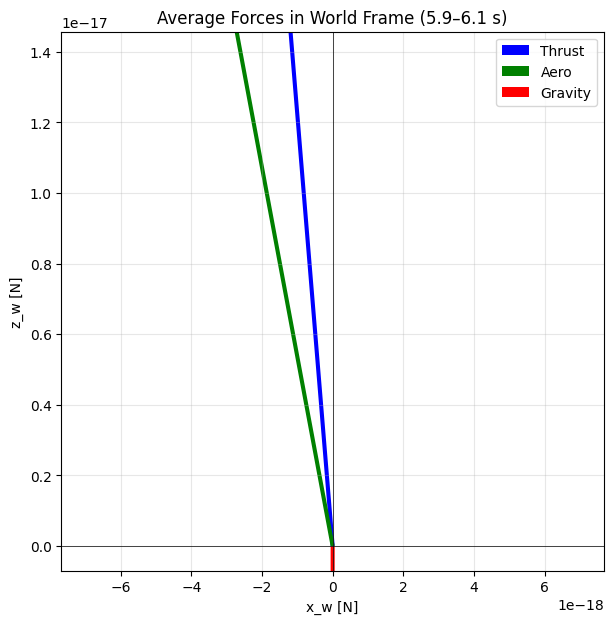

In [98]:
## Plot average forces in world frame (side view x–z)

import matplotlib.pyplot as plt

# Extract components (world frame)
Ft = Ft_mean
Fa = Fa_mean
Fg = Fg_mean

# Origin for the arrows
x0, z0 = 0.0, 0.0

# Scale factor so arrows are visible
scale = 1.0  # increase if arrows too small

plt.figure(figsize=(7, 7))

# Thrust
plt.quiver(
    x0, z0,
    Ft[0] * scale, Ft[2] * scale,
    angles='xy', scale_units='xy', scale=1,
    color='blue', label='Thrust'
)

# Aerodynamic
plt.quiver(
    x0, z0,
    Fa[0] * scale, Fa[2] * scale,
    angles='xy', scale_units='xy', scale=1,
    color='green', label='Aero'
)

# Gravity
plt.quiver(
    x0, z0,
    Fg[0] * scale, Fg[2] * scale,
    angles='xy', scale_units='xy', scale=1,
    color='red', label='Gravity'
)

# Axes styling
plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)
plt.grid(True, alpha=0.3)

plt.xlabel("x_w [N]")
plt.ylabel("z_w [N]")
plt.title("Average Forces in World Frame (5.9–6.1 s)")
plt.legend()

plt.axis('equal')
plt.show()


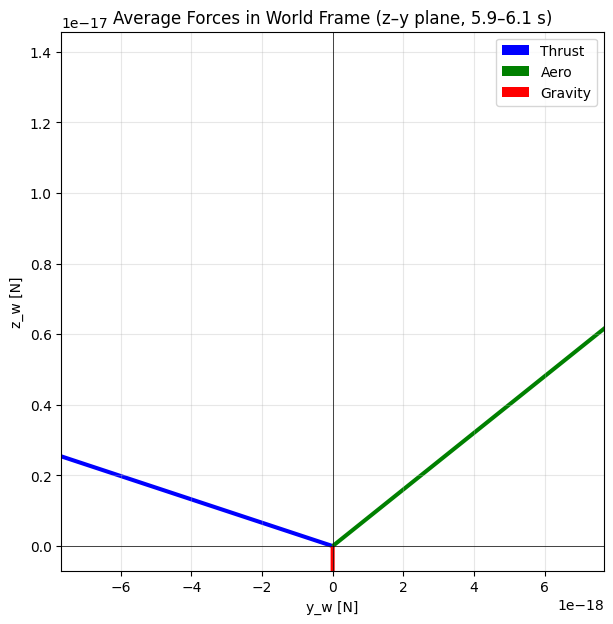

In [99]:
## Plot average forces in world frame (z–y plane)

import matplotlib.pyplot as plt

Ft = Ft_mean     # thrust avg [Fx, Fy, Fz]
Fa = Fa_mean     # aero avg
Fg = Fg_mean     # gravity avg

# Origin for arrows
y0, z0 = 0.0, 0.0

# Scale factor so arrows are visible
scale = 1.0

plt.figure(figsize=(7, 7))

# Thrust
plt.quiver(
    y0, z0,
    Ft[1] * scale, Ft[2] * scale,
    angles='xy', scale_units='xy', scale=1,
    color='blue', label='Thrust'
)

# Aerodynamic
plt.quiver(
    y0, z0,
    Fa[1] * scale, Fa[2] * scale,
    angles='xy', scale_units='xy', scale=1,
    color='green', label='Aero'
)

# Gravity
plt.quiver(
    y0, z0,
    Fg[1] * scale, Fg[2] * scale,
    angles='xy', scale_units='xy', scale=1,
    color='red', label='Gravity'
)

plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)
plt.grid(True, alpha=0.3)

plt.xlabel("y_w [N]")
plt.ylabel("z_w [N]")
plt.title("Average Forces in World Frame (z–y plane, 5.9–6.1 s)")
plt.legend()

plt.axis('equal')
plt.show()


## 13. Save Combined Data

In [100]:
# Save combined data

out_path = data_dir / "8mps_imu_aero_combined.csv"
combined.to_csv(out_path, index=False)
print(f"Saved combined dataset to: {out_path}")
print(f"Rows: {len(combined)}, columns: {len(combined.columns)}")

Saved combined dataset to: /home/nebu/Documents/TUM/Masterarbeit/MasterTheses/logs/Circle/12mps_line/8mps_imu_aero_combined.csv
Rows: 23584, columns: 69
